# 5.2. 에르미트 연산자와 측정값

In [1]:
import numpy as np
from scipy.constants import hbar, m_e, e

L, N = 1e-9, 1000
dx = L / (N + 1)
x = np.linspace(0, L, N + 2)[1:-1]

D1 = (np.eye(N, k=1) - np.eye(N, k=-1)) / (2 * dx)
D2 = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2

X = np.diag(x)  # 위치
P = -1j * hbar * D1  # 운동량
T = -(hbar**2) / (2 * m_e) * D2  # 운동에너지


def check(M, name):
    diff = np.max(np.abs(M - M.conj().T))
    print(
        f"{name:14s} |M - M^dagger| = {diff:.3e}   에르미트? {np.allclose(M, M.conj().T)}"
    )


check(X, "x")
check(P, "p")
check(T, "T")
check(D1, "D1 (i 없이)")

x              |M - M^dagger| = 0.000e+00   에르미트? True
p              |M - M^dagger| = 0.000e+00   에르미트? True
T              |M - M^dagger| = 0.000e+00   에르미트? True
D1 (i 없이)      |M - M^dagger| = 1.001e+12   에르미트? False


In [2]:
for M, name in [(X, "x"), (P, "p"), (T, "T"), (D1, "D1")]:
    ev = np.linalg.eigvals(M)
    print(
        f"{name:3s}: 실수부 최대 {np.max(np.abs(ev.real)):.3e}  허수부 최대 {np.max(np.abs(ev.imag)):.3e}"
    )

x  : 실수부 최대 9.990e-10  허수부 최대 0.000e+00
p  : 실수부 최대 1.056e-22  허수부 최대 0.000e+00
T  : 실수부 최대 2.447e-14  허수부 최대 0.000e+00
D1 : 실수부 최대 2.747e-04  허수부 최대 1.001e+12


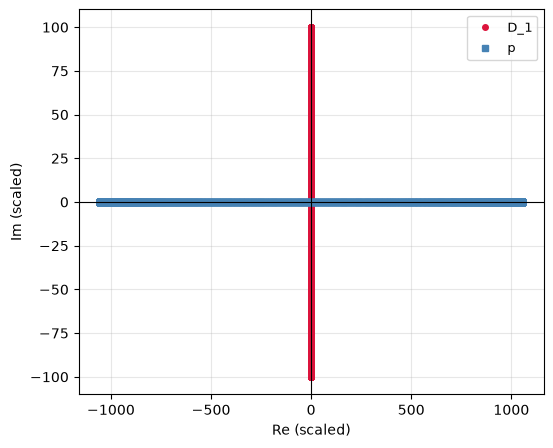

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
evD1 = np.linalg.eigvals(D1)
evP = np.linalg.eigvals(P)

ax.plot(evD1.real / 1e10, evD1.imag / 1e10, "o", ms=4, color="crimson", label="D_1")
ax.plot(evP.real / 1e-25, evP.imag / 1e-25, "s", ms=4, color="steelblue", label="p")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Re (scaled)")
ax.set_ylabel("Im (scaled)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

In [4]:
def psi(n):
    return np.sqrt(2 / L) * np.sin(n * np.pi * x / L)


print("      " + "".join(f"{'n='+str(n):>10}" for n in range(1, 4)))
for m in range(1, 4):
    row = "".join(f"{np.trapezoid(psi(m)*psi(n), x):10.5f}" for n in range(1, 4))
    print(f"m = {m} {row}")

             n=1       n=2       n=3
m = 1    1.00000   0.00000  -0.00000
m = 2    0.00000   1.00000   0.00000
m = 3   -0.00000   0.00000   1.00000
